In [15]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [16]:
# Load the KDD Cup 1999 dataset (Replace the path with your dataset path)
# Assuming the dataset is in CSV format
# Load the dataset
column_names = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
                'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
                'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
                'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
                'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
                'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
                'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
                'dst_host_srv_rerror_rate', 'label']

data = pd.read_csv('kddcup.data', header=None, names=column_names)

In [17]:
data.shape

(4898431, 42)

In [18]:
data.head(5)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,http,SF,215,45076,0,0,0,0,...,0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,normal.
1,0,tcp,http,SF,162,4528,0,0,0,0,...,1,1.0,0.0,1.00,0.0,0.0,0.0,0.0,0.0,normal.
2,0,tcp,http,SF,236,1228,0,0,0,0,...,2,1.0,0.0,0.50,0.0,0.0,0.0,0.0,0.0,normal.
3,0,tcp,http,SF,233,2032,0,0,0,0,...,3,1.0,0.0,0.33,0.0,0.0,0.0,0.0,0.0,normal.
4,0,tcp,http,SF,239,486,0,0,0,0,...,4,1.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0,normal.


In [19]:
# Identify categorical columns (e.g., protocol_type, service, flag)
categorical_columns = ['protocol_type', 'service', 'flag']

# Apply label encoding to the categorical columns
label_encoder = LabelEncoder()
for col in categorical_columns:
    data[col] = label_encoder.fit_transform(data[col])

# Split data into features and target variable
X = data.drop(columns=['label'])
y = data['label']

# Encoding the target variable (if it is categorical)
y = label_encoder.fit_transform(y)

In [20]:
# Split into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [21]:
# LightGBM model
params = {
    'objective': 'multiclass',
    'num_class': len(np.unique(y)),  # Number of unique classes
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9
}

train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val)

# Training the model with early stopping callback
early_stopping_callback = lgb.callback.early_stopping(stopping_rounds=50)

model = lgb.train(params, train_data, valid_sets=[val_data], num_boost_round=1000, callbacks=[early_stopping_callback])

# Predict on test set
y_pred = model.predict(X_test, num_iteration=model.best_iteration)
y_pred_class = np.argmax(y_pred, axis=1)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred_class)
conf_matrix = confusion_matrix(y_test, y_pred_class)
precision = precision_score(y_test, y_pred_class, average='weighted')
recall = recall_score(y_test, y_pred_class, average='weighted')
f1 = f1_score(y_test, y_pred_class, average='weighted')

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print(f'Confusion Matrix:\n {conf_matrix}')




[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.123646 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2685
[LightGBM] [Info] Number of data points in the train set: 3428901, number of used features: 38
[LightGBM] [Info] Start training from score -7.708862
[LightGBM] [Info] Start training from score -12.052018
[LightGBM] [Info] Start training from score -13.661456
[LightGBM] [Info] Start training from score -11.358871
[LightGBM] [Info] Start training from score -12.649855
[LightGBM] [Info] Start training from score -5.968430
[LightGBM] [Info] Start training from score -12.649855
[LightGBM] [Info] Start training from score -13.255991
[LightGBM] [Info] Start training from score -13.255991
[LightGBM] [Info] Start training from score -1.519642
[LightGBM] [Info] Start training from score -7.680673
[LightGBM] [Info] Start training from score 

c:\Users\user4\Anaconda3\envs\vivek\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print(f'Confusion Matrix:\n {conf_matrix}')

Accuracy: 0.994896327397195
Precision: 0.9969919009270106
Recall: 0.994896327397195
F1 Score: 0.9958250873166011
Confusion Matrix:
 [[   313      0      0      0      0      0      0      0      0      0
       0      6      0      0      0      0      0      0      0      0
       0      0      0]
 [     1      0      0      0      0      0      0      0      0      0
       0      7      0      0      0      0      0      0      0      0
       0      0      0]
 [     0      0      0      0      0      0      0      0      0      0
       0      2      0      0      0      0      0      1      0      0
       0      0      0]
 [     0      0      0      0      0      0      0      0      0      0
       0      6      0      0      0      0      0      0      0      0
       0      0      0]
 [     0      0      0      0      0      0      0      0      0      0
       0      1      0      0      0      0      0      0      0      0
       0      0      0]
 [     0      0      1      

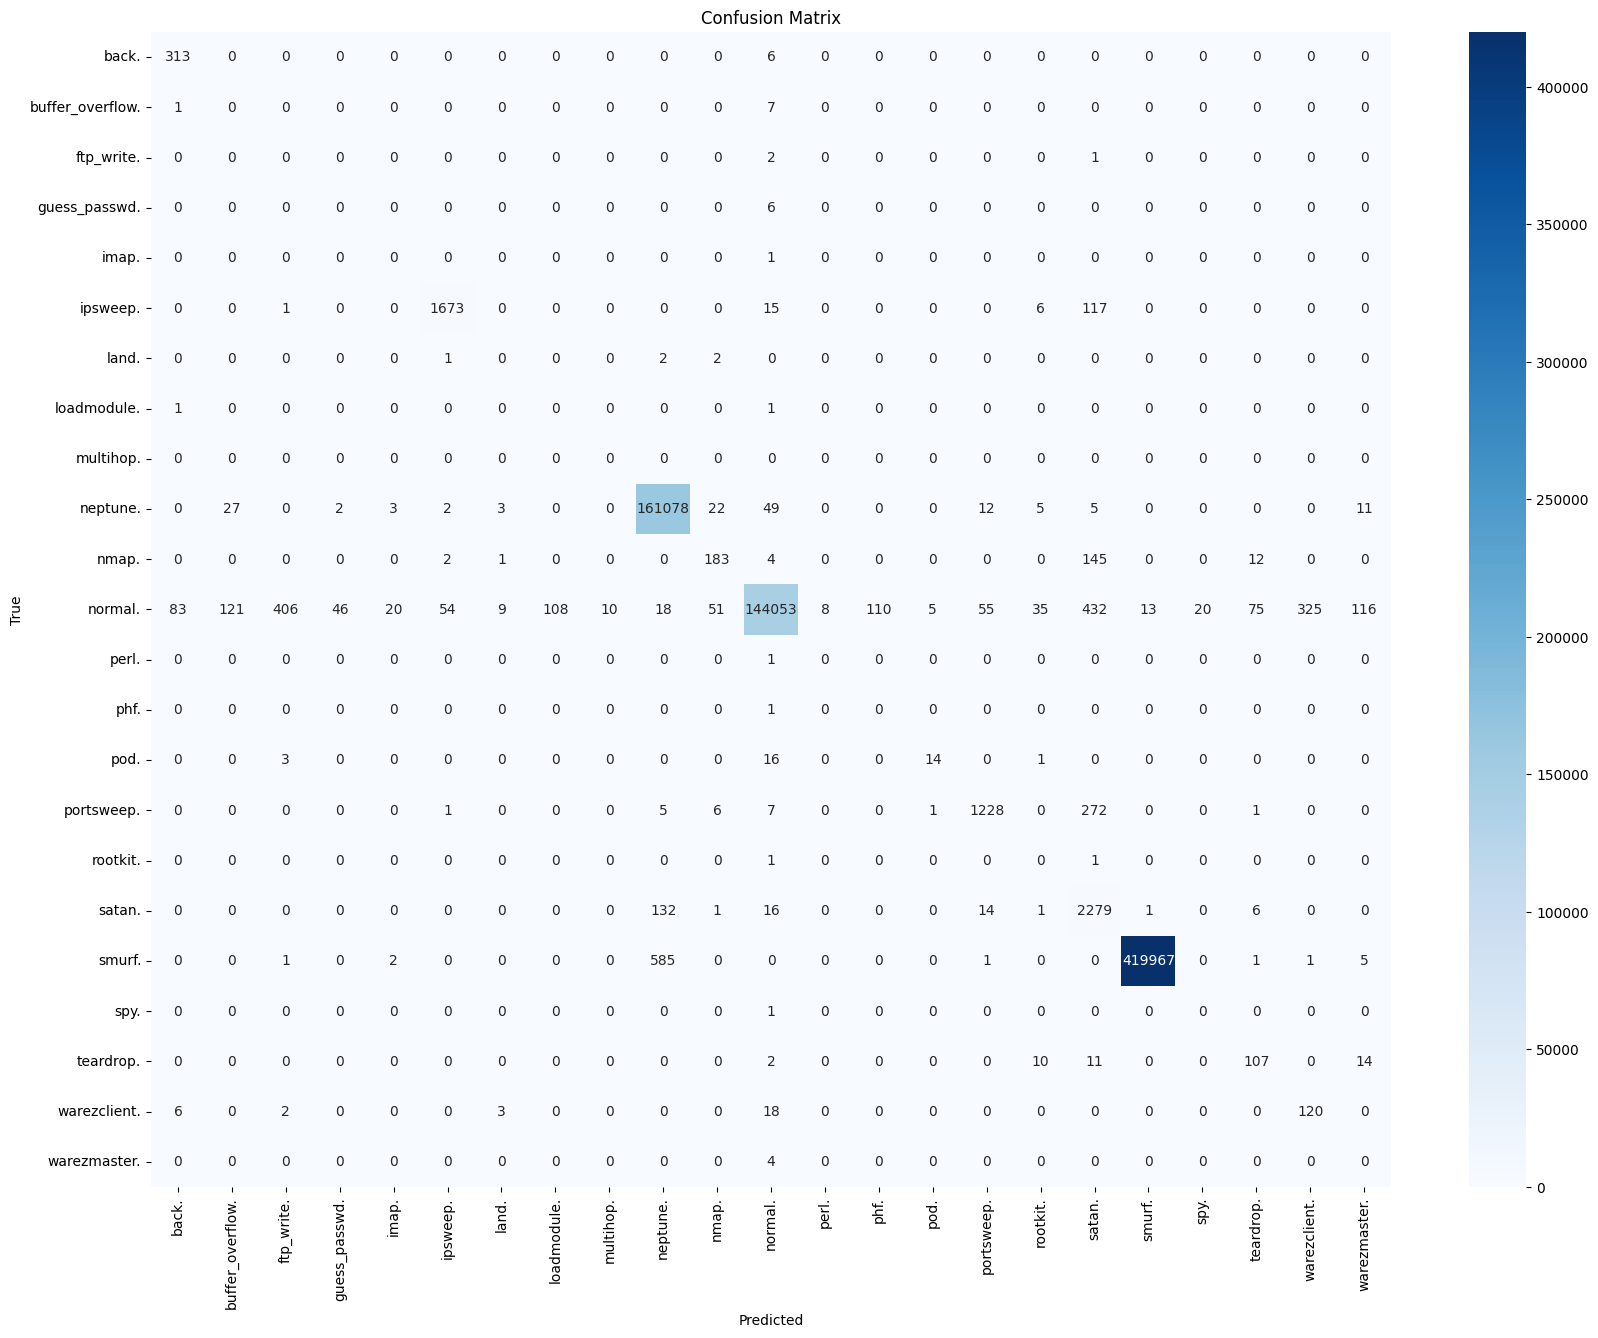

In [23]:
# Plot Confusion Matrix
plt.figure(figsize=(20, 15))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()



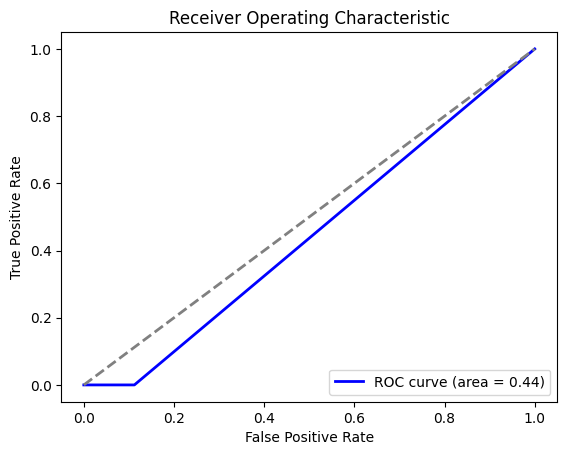

In [24]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred[:, 1], pos_label=1)  # Plot for class 1 (modify for multi-class)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()



c:\Users\user4\Anaconda3\envs\vivek\lib\site-packages\sklearn\metrics\_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


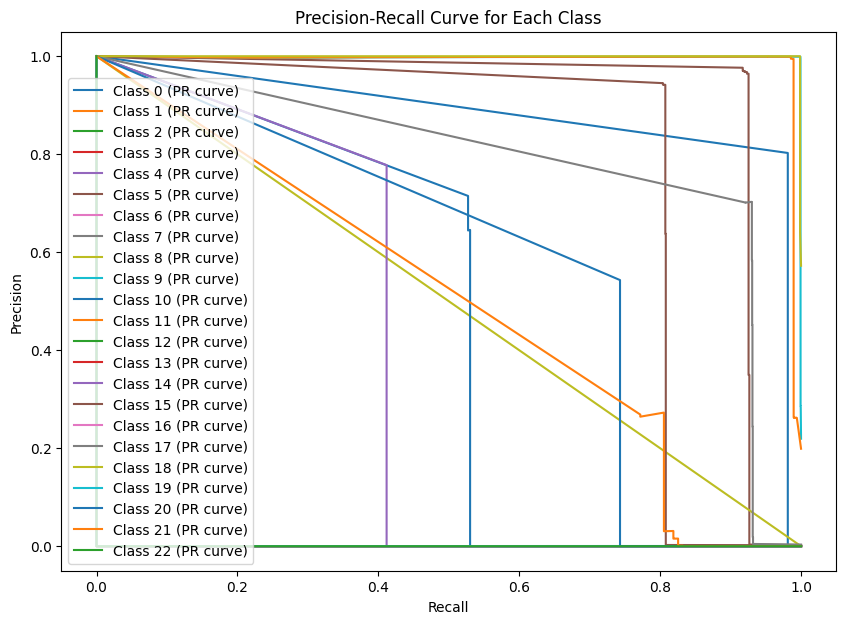

In [26]:
# Precision-Recall Curve for Multiclass Classification
# One curve per class
plt.figure(figsize=(10, 7))

# Loop over all classes to plot precision-recall curve for each
for i in range(len(np.unique(y))):
    precision_vals, recall_vals, _ = precision_recall_curve(y_test == i, y_pred[:, i])  # For class i
    plt.plot(recall_vals, precision_vals, label=f'Class {i} (PR curve)')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Each Class')
plt.legend(loc='lower left')
plt.show()